# Cauchy Residual Mixer vs Standard Residual on PDE (PINN-style)

目标 PDE（Poisson 方程）：
$$-\Delta u(x,y) = 2\pi^2\sin(\pi x)\sin(\pi y),\quad (x,y)\in[-1,1]^2$$

边界条件：
$$u(x,y)=0,\quad (x,y)\in\partial[-1,1]^2$$

解析解：
$$u^*(x,y)=\sin(\pi x)\sin(\pi y)$$

实验设置：
- 使用类似 PINN 的损失：`L = L_pde + w_bc * L_bc`
- 主干网络统一为 30 层 MLP（输入 2 维，输出 1 维）
- 对比 4 种架构（残差方式 x 激活函数）
- 用解析解在网格上评估 MSE

In [1]:
import sys
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm import tqdm

repo_root = Path.cwd().resolve()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from cauchy_res_mixer import CauchyResidualMLP

random_seed = int(time.perf_counter())
np.random.seed(random_seed)
torch.manual_seed(random_seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
PI = float(np.pi)


def u_exact_numpy(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.sin(PI * x) * np.sin(PI * y)


def rhs_numpy(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    # -Delta u = 2*pi^2*sin(pi x)*sin(pi y)
    return 2.0 * (PI**2) * np.sin(PI * x) * np.sin(PI * y)


def rhs_torch(xy: torch.Tensor) -> torch.Tensor:
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    return 2.0 * (PI**2) * torch.sin(PI * x) * torch.sin(PI * y)


def sample_interior(n: int) -> np.ndarray:
    # interior points in (-1, 1)^2
    return np.random.uniform(-1.0, 1.0, size=(n, 2)).astype(np.float32)


def sample_boundary(n_per_edge: int) -> np.ndarray:
    s = np.random.uniform(-1.0, 1.0, size=(n_per_edge, 1)).astype(np.float32)
    left = np.concatenate([-np.ones_like(s), s], axis=1)
    right = np.concatenate([np.ones_like(s), s], axis=1)
    bottom = np.concatenate([s, -np.ones_like(s)], axis=1)
    top = np.concatenate([s, np.ones_like(s)], axis=1)
    return np.concatenate([left, right, bottom, top], axis=0).astype(np.float32)


n_interior = 4096
n_boundary_each = 1024
x_interior_np = sample_interior(n_interior)
x_boundary_np = sample_boundary(n_boundary_each)

x_interior = torch.tensor(x_interior_np, dtype=torch.float32, device=device)
x_boundary = torch.tensor(x_boundary_np, dtype=torch.float32, device=device)

x_interior.shape, x_boundary.shape

(torch.Size([4096, 2]), torch.Size([4096, 2]))

In [3]:
def pinn_loss(model: nn.Module, x_int: torch.Tensor, x_bc: torch.Tensor, w_bc: float = 20.0):
    x_int = x_int.clone().detach().requires_grad_(True)
    u = model(x_int)

    grad_u = torch.autograd.grad(
        outputs=u,
        inputs=x_int,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True,
    )[0]
    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]

    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x_int,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True,
    )[0][:, 0:1]
    u_yy = torch.autograd.grad(
        outputs=u_y,
        inputs=x_int,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True,
        retain_graph=True,
    )[0][:, 1:2]

    residual = -(u_xx + u_yy) - rhs_torch(x_int)
    loss_pde = torch.mean(residual.pow(2))

    u_bc = model(x_bc)
    loss_bc = torch.mean(u_bc.pow(2))

    loss = loss_pde + w_bc * loss_bc
    return loss, loss_pde.detach(), loss_bc.detach()

In [4]:
def train_pinn(
    residual_mode: str,
    activation_mode: str,
    epochs: int = 1000,
    lr: float = 1e-3,
    w_bc: float = 20.0,
):
    model = CauchyResidualMLP(
        input_dim=2,
        hidden_dim=128,
        num_classes=1,
        num_layers=30,
        activation_mode=activation_mode,
        residual_mode=residual_mode,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-6)

    total_hist = []
    pde_hist = []
    bc_hist = []

    pbar = tqdm(
        range(epochs),
        desc=f"Training {residual_mode} - {activation_mode}",
    )

    for _ in pbar:
        model.train()
        optimizer.zero_grad(set_to_none=True)

        loss, loss_pde, loss_bc = pinn_loss(model, x_interior, x_boundary, w_bc=w_bc)
        loss.backward()
        optimizer.step()

        total_hist.append(float(loss.item()))
        pde_hist.append(float(loss_pde.item()))
        bc_hist.append(float(loss_bc.item()))

        pbar.set_postfix_str(
            f"total: {total_hist[-1]:.4e}, pde: {pde_hist[-1]:.4e}, bc: {bc_hist[-1]:.4e}"
        )

    return model, total_hist, pde_hist, bc_hist

Training standard - cauchy:   0%|          | 0/1200 [00:00<?, ?it/s]/data1/linjiangtao2024/cauchy_activation/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Training cauchy - relu: 100%|██████████| 1200/1200 [15:54<00:00,  1.26it/s, total: 3.4778e-01, pde: 3.0369e-01, bc: 2.2047e-03]


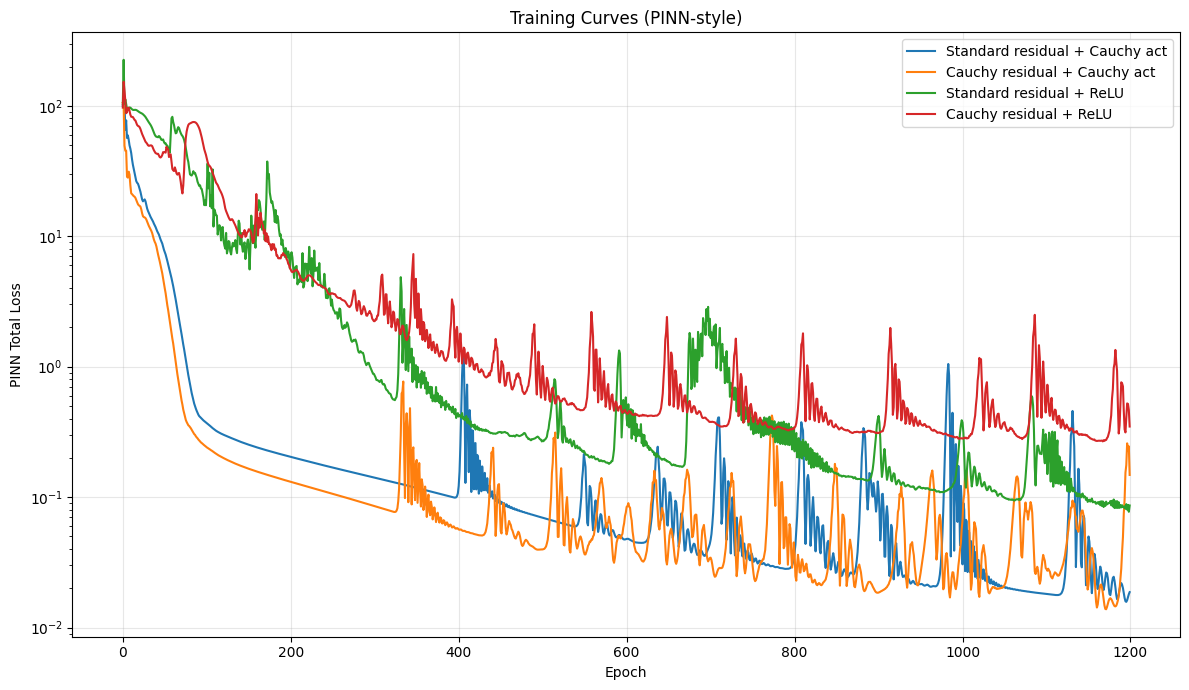

In [5]:
epochs = 1200
lr = 1e-3
w_bc = 20.0

model_std_cauchy, loss_std_cauchy, pde_std_cauchy, bc_std_cauchy = train_pinn(
    residual_mode="standard",
    activation_mode="cauchy",
    epochs=epochs,
    lr=lr,
    w_bc=w_bc,
)

model_cauchy_cauchy, loss_cauchy_cauchy, pde_cauchy_cauchy, bc_cauchy_cauchy = train_pinn(
    residual_mode="cauchy",
    activation_mode="cauchy",
    epochs=epochs,
    lr=lr,
    w_bc=w_bc,
)

model_std_relu, loss_std_relu, pde_std_relu, bc_std_relu = train_pinn(
    residual_mode="standard",
    activation_mode="relu",
    epochs=epochs,
    lr=lr,
    w_bc=w_bc,
)

model_cauchy_relu, loss_cauchy_relu, pde_cauchy_relu, bc_cauchy_relu = train_pinn(
    residual_mode="cauchy",
    activation_mode="relu",
    epochs=epochs,
    lr=lr,
    w_bc=w_bc,
)

plt.figure(figsize=(12, 7))
plt.plot(loss_std_cauchy, label="Standard residual + Cauchy act")
plt.plot(loss_cauchy_cauchy, label="Cauchy residual + Cauchy act")
plt.plot(loss_std_relu, label="Standard residual + ReLU")
plt.plot(loss_cauchy_relu, label="Cauchy residual + ReLU")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("PINN Total Loss")
plt.title("Training Curves (PINN-style)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Comparison to analytic solution on dense grid:
Standard residual + Cauchy act MSE: 1.081459e-04
Cauchy residual + Cauchy act MSE:   5.025390e-04
Standard residual + ReLU MSE:       3.124968e-01
Cauchy residual + ReLU MSE:         1.592578e-01


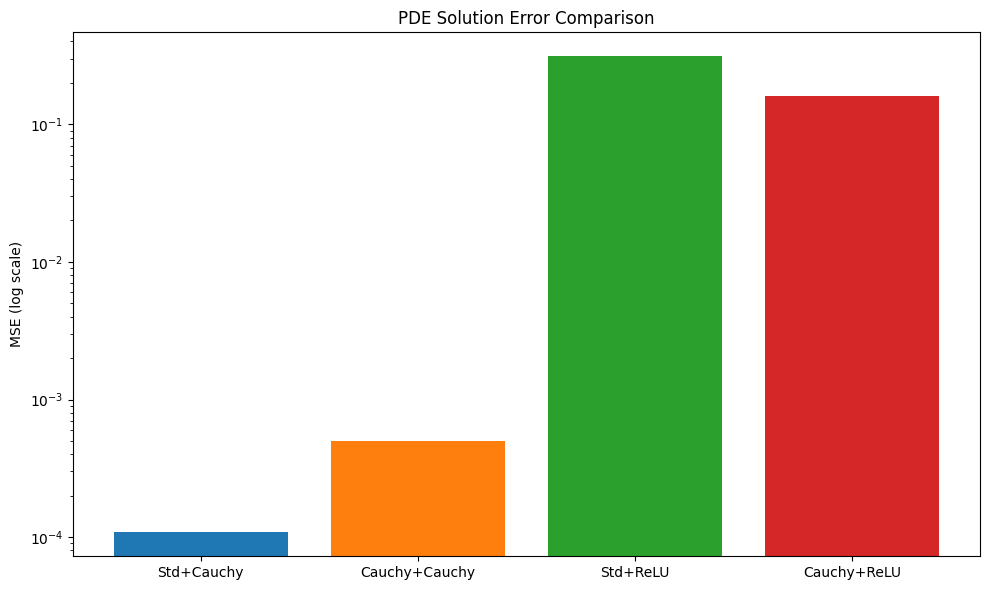

In [6]:
n_eval = 120
xv = np.linspace(-1.0, 1.0, n_eval, dtype=np.float32)
yv = np.linspace(-1.0, 1.0, n_eval, dtype=np.float32)
X, Y = np.meshgrid(xv, yv)
xy_eval = np.stack([X.reshape(-1), Y.reshape(-1)], axis=1).astype(np.float32)
xy_eval_t = torch.tensor(xy_eval, dtype=torch.float32, device=device)

u_true = u_exact_numpy(xy_eval[:, 0:1], xy_eval[:, 1:2])

with torch.no_grad():
    u_std_cauchy = model_std_cauchy(xy_eval_t).cpu().numpy()
    u_cauchy_cauchy = model_cauchy_cauchy(xy_eval_t).cpu().numpy()
    u_std_relu = model_std_relu(xy_eval_t).cpu().numpy()
    u_cauchy_relu = model_cauchy_relu(xy_eval_t).cpu().numpy()

mse_std_cauchy = float(np.mean((u_std_cauchy - u_true) ** 2))
mse_cauchy_cauchy = float(np.mean((u_cauchy_cauchy - u_true) ** 2))
mse_std_relu = float(np.mean((u_std_relu - u_true) ** 2))
mse_cauchy_relu = float(np.mean((u_cauchy_relu - u_true) ** 2))

print("Comparison to analytic solution on dense grid:")
print(f"Standard residual + Cauchy act MSE: {mse_std_cauchy:.6e}")
print(f"Cauchy residual + Cauchy act MSE:   {mse_cauchy_cauchy:.6e}")
print(f"Standard residual + ReLU MSE:       {mse_std_relu:.6e}")
print(f"Cauchy residual + ReLU MSE:         {mse_cauchy_relu:.6e}")

plt.figure(figsize=(10, 6))
labels = [
    "Std+Cauchy",
    "Cauchy+Cauchy",
    "Std+ReLU",
    "Cauchy+ReLU",
]
values = [mse_std_cauchy, mse_cauchy_cauchy, mse_std_relu, mse_cauchy_relu]
plt.bar(labels, values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
plt.yscale("log")
plt.ylabel("MSE (log scale)")
plt.title("PDE Solution Error Comparison")
plt.tight_layout()
plt.show()

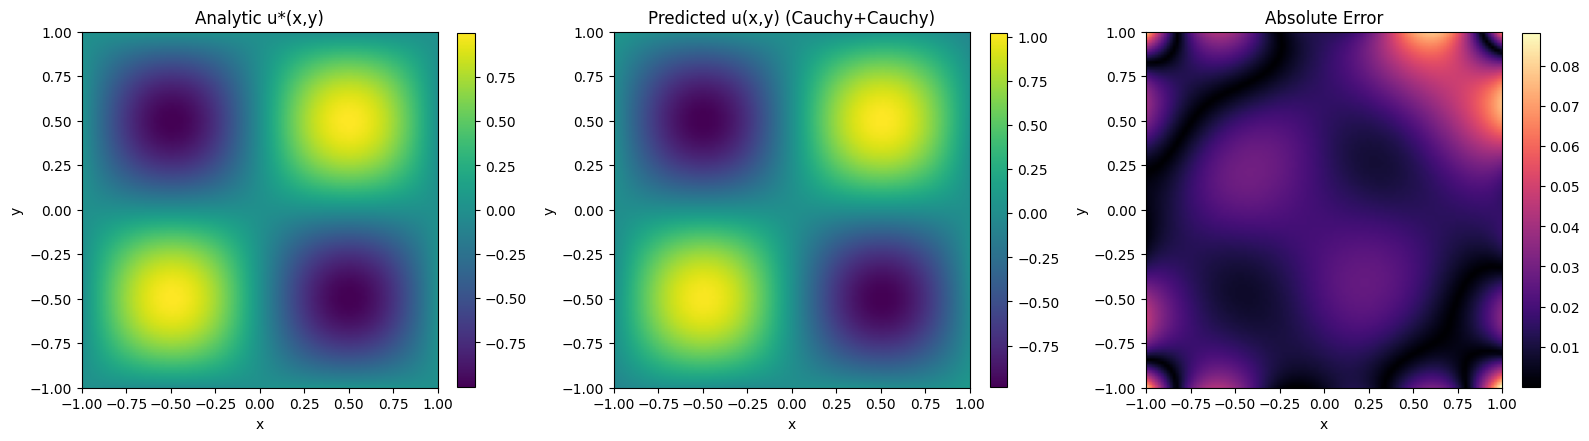

In [7]:
u_true_img = u_true.reshape(n_eval, n_eval)
u_best = u_cauchy_cauchy.reshape(n_eval, n_eval)
err_best = np.abs(u_best - u_true_img)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

im0 = axes[0].imshow(u_true_img, extent=[-1, 1, -1, 1], origin="lower", cmap="viridis")
axes[0].set_title("Analytic u*(x,y)")
plt.colorbar(im0, ax=axes[0], fraction=0.045)

im1 = axes[1].imshow(u_best, extent=[-1, 1, -1, 1], origin="lower", cmap="viridis")
axes[1].set_title("Predicted u(x,y) (Cauchy+Cauchy)")
plt.colorbar(im1, ax=axes[1], fraction=0.045)

im2 = axes[2].imshow(err_best, extent=[-1, 1, -1, 1], origin="lower", cmap="magma")
axes[2].set_title("Absolute Error")
plt.colorbar(im2, ax=axes[2], fraction=0.045)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()